In [17]:
# Cell 1 - Imports

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [18]:
# Cell 2 - Paths and settings

BASE_DIR = Path("/Users/tonytony/Final Project")
RAW_DIR = BASE_DIR / "Data" / "Raw"
CLEAN_DIR = BASE_DIR / "Data" / "Cleaned"

PANEL_PATH = CLEAN_DIR / "panel_with_event_dummies_and_extra_drivers.csv"
GDP_PATH = RAW_DIR / "gdp.csv"
POP_PATH = RAW_DIR / "population.csv"
LIFE_PATH = RAW_DIR / "life_expectancy.csv"
INFLATION_PATH = RAW_DIR / "inflation.csv"
UNEMPLOYMENT_PATH = RAW_DIR / "unemployment.csv"
META_PATH = RAW_DIR / "world_bank_country_metadata.csv"

internet_candidates = [
    RAW_DIR / "individuals_using_the_Internet.csv",
    RAW_DIR / "individuals_using_ the_Internet.csv"
]

INTERNET_PATH = None
for candidate in internet_candidates:
    if candidate.exists():
        INTERNET_PATH = candidate
        break

if INTERNET_PATH is None:
    raise FileNotFoundError(
        "Internet dataset file was not found in Data/Raw. "
        "Expected one of: individuals_using_the_Internet.csv or individuals_using_ the_Internet.csv"
    )

COUNTRY_CODE_INPUT = "VNM"
TARGET_YEAR_INPUT = 2040

POP_FORECAST_MODEL = "LogHolt"
LIFE_FORECAST_MODEL = "Holt"
INFLATION_FORECAST_MODEL = "Naive"
UNEMPLOYMENT_FORECAST_MODEL = "Naive"
INTERNET_FORECAST_MODEL = "Holt"

print("Panel path:", PANEL_PATH)
print("GDP path:", GDP_PATH)
print("Population path:", POP_PATH)
print("Life path:", LIFE_PATH)
print("Inflation path:", INFLATION_PATH)
print("Unemployment path:", UNEMPLOYMENT_PATH)
print("Internet path:", INTERNET_PATH)
print("Metadata path:", META_PATH)
print("Country:", COUNTRY_CODE_INPUT)
print("Target year:", TARGET_YEAR_INPUT)

Panel path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
GDP path: /Users/tonytony/Final Project/Data/Raw/gdp.csv
Population path: /Users/tonytony/Final Project/Data/Raw/population.csv
Life path: /Users/tonytony/Final Project/Data/Raw/life_expectancy.csv
Inflation path: /Users/tonytony/Final Project/Data/Raw/inflation.csv
Unemployment path: /Users/tonytony/Final Project/Data/Raw/unemployment.csv
Internet path: /Users/tonytony/Final Project/Data/Raw/individuals_using_ the_Internet.csv
Metadata path: /Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv
Country: VNM
Target year: 2040


In [19]:
# Cell 3 - Helper functions for World Bank raw data

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    return df


def to_long(df, value_name):
    year_cols = [col for col in df.columns if str(col).isdigit()]
    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=year_cols,
        var_name="year",
        value_name=value_name
    )
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce")
    return long_df


def load_metadata():
    meta = pd.read_csv(META_PATH)

    meta = meta.rename(
        columns={
            "Country Code": "country_code",
            "World Bank Name": "country_name",
            "World Bank Region": "wb_region"
        }
    )

    meta = meta[["country_code", "country_name", "wb_region"]].copy()
    meta["country_code"] = meta["country_code"].astype(str).str.strip()
    meta["country_name"] = meta["country_name"].astype(str).str.strip()
    meta["wb_region"] = meta["wb_region"].astype(str).str.strip()

    meta = meta[meta["wb_region"].notna()].copy()
    meta = meta[meta["wb_region"] != ""].copy()
    meta = meta[meta["wb_region"].str.lower() != "aggregates"].copy()

    return meta


def add_region_info(long_df, value_col):
    meta = load_metadata()

    out = long_df.rename(
        columns={
            "Country Name": "country_name",
            "Country Code": "country_code"
        }
    ).copy()

    out["country_code"] = out["country_code"].astype(str).str.strip()
    out["country_name"] = out["country_name"].astype(str).str.strip()

    out = out.merge(meta, on="country_code", how="left", suffixes=("", "_meta"))

    if "country_name_meta" in out.columns:
        out["country_name"] = out["country_name_meta"].fillna(out["country_name"])
        out = out.drop(columns=["country_name_meta"], errors="ignore")

    out = out[["country_name", "country_code", "wb_region", "year", value_col]].copy()
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")

    out = out.dropna(subset=["country_code", "year"])
    out["year"] = out["year"].astype(int)

    return out

In [20]:
# Cell 4 - Load raw long series

gdp_long = add_region_info(
    to_long(load_wdi(GDP_PATH), "gdp_per_capita_usd"),
    "gdp_per_capita_usd"
)

pop_long = add_region_info(
    to_long(load_wdi(POP_PATH), "population_total"),
    "population_total"
)

life_long = add_region_info(
    to_long(load_wdi(LIFE_PATH), "life_expectancy_years"),
    "life_expectancy_years"
)

inflation_long = add_region_info(
    to_long(load_wdi(INFLATION_PATH), "inflation_pct"),
    "inflation_pct"
)

unemployment_long = add_region_info(
    to_long(load_wdi(UNEMPLOYMENT_PATH), "unemployment_pct"),
    "unemployment_pct"
)

internet_long = add_region_info(
    to_long(load_wdi(INTERNET_PATH), "internet_users_pct"),
    "internet_users_pct"
)

gdp_long = gdp_long[gdp_long["gdp_per_capita_usd"].notna()].copy()
pop_long = pop_long[pd.to_numeric(pop_long["population_total"], errors="coerce").notna()].copy()
life_long = life_long[pd.to_numeric(life_long["life_expectancy_years"], errors="coerce").notna()].copy()
inflation_long = inflation_long[pd.to_numeric(inflation_long["inflation_pct"], errors="coerce").notna()].copy()
unemployment_long = unemployment_long[pd.to_numeric(unemployment_long["unemployment_pct"], errors="coerce").notna()].copy()
internet_long = internet_long[pd.to_numeric(internet_long["internet_users_pct"], errors="coerce").notna()].copy()

print("GDP long:", gdp_long.shape)
print("Population long:", pop_long.shape)
print("Life long:", life_long.shape)
print("Inflation long:", inflation_long.shape)
print("Unemployment long:", unemployment_long.shape)
print("Internet long:", internet_long.shape)

GDP long: (14561, 5)
Population long: (17195, 5)
Life long: (16926, 5)
Inflation long: (9066, 5)
Unemployment long: (8211, 5)
Internet long: (6917, 5)


In [21]:
# Cell 5 - Load panel data for XGBoost Model 3

def slugify_text(text):
    text = str(text).strip().lower()
    chars = []
    for ch in text:
        if ch.isalnum():
            chars.append(ch)
        else:
            chars.append("_")
    out = "".join(chars)
    while "__" in out:
        out = out.replace("__", "_")
    return out.strip("_")


model_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024"
]

panel_df = pd.read_csv(PANEL_PATH, usecols=model_cols)

numeric_cols = [
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024"
]

for col in numeric_cols:
    panel_df[col] = pd.to_numeric(panel_df[col], errors="coerce")

panel_df["country_name"] = panel_df["country_name"].astype(str)
panel_df["country_code"] = panel_df["country_code"].astype(str)
panel_df["wb_region"] = panel_df["wb_region"].astype(str)

model_df = panel_df.dropna().copy()
model_df["year"] = model_df["year"].astype(int)

BASE_FEATURE_YEAR = int(model_df["year"].min())
model_df["year_trend"] = model_df["year"] - BASE_FEATURE_YEAR

region_values = sorted(model_df["wb_region"].dropna().astype(str).unique().tolist())

region_feature_map = {}
used_feature_names = set()

for region_name in region_values:
    base_name = f"region__{slugify_text(region_name)}"
    feature_name = base_name
    suffix = 2
    while feature_name in used_feature_names:
        feature_name = f"{base_name}_{suffix}"
        suffix += 1
    region_feature_map[region_name] = feature_name
    used_feature_names.add(feature_name)
    model_df[feature_name] = (model_df["wb_region"] == region_name).astype(int)

region_feature_cols = list(region_feature_map.values())

print("Model 3 panel shape:", model_df.shape)
print("Base feature year:", BASE_FEATURE_YEAR)
print("Regions:", len(region_feature_cols))
print("Feature year range:", int(model_df["year"].min()), "-", int(model_df["year"].max()))
print("Target year range:", int((model_df["year"] + 1).min()), "-", int((model_df["year"] + 1).max()))

display(model_df.head())
print(region_feature_map)

Model 3 panel shape: (4722, 26)
Base feature year: 1991
Regions: 7
Feature year range: 1991 - 2022
Target year range: 1992 - 2023


,country_name,country_code,wb_region,year,gdp_per_capita_usd,life_expectancy_years,population_total,log_gdp_per_capita,log_population_total,target_log_gdp_next_year,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,year_trend,region__east_asia_pacific,region__europe_central_asia,region__latin_america_caribbean,region__middle_east_north_africa_afghanistan_pakistan,region__north_america,region__south_asia,region__sub_saharan_africa
43,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2005,254.1842,58.2470,"24,404,567.0000",5.5381,17.0103,5.6139,0,0,0,0,0,12.6863,7.8780,1.2241,14,0,0,0,1,0,0,0
44,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2006,274.2186,58.5530,"25,424,094.0000",5.6139,17.0512,5.9302,0,0,0,0,0,6.7846,7.8970,2.1071,15,0,0,0,1,0,0,0
45,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2007,376.2232,58.9560,"25,909,852.0000",5.9302,17.0701,5.9447,0,0,0,0,0,8.6806,7.8410,1.9000,16,0,0,0,1,0,0,0
46,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2008,381.7332,59.7080,"26,482,622.0000",5.9447,17.0920,6.1138,0,1,0,0,0,26.4187,7.8790,1.8400,17,0,0,0,1,0,0,0
47,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2009,452.0537,60.2480,"27,466,101.0000",6.1138,17.1285,6.3290,0,1,0,0,0,-2.8285,7.8080,3.5500,18,0,0,0,1,0,0,0


{'East Asia & Pacific': 'region__east_asia_pacific', 'Europe & Central Asia': 'region__europe_central_asia', 'Latin America & Caribbean ': 'region__latin_america_caribbean', 'Middle East, North Africa, Afghanistan & Pakistan': 'region__middle_east_north_africa_afghanistan_pakistan', 'North America': 'region__north_america', 'South Asia': 'region__south_asia', 'Sub-Saharan Africa ': 'region__sub_saharan_africa'}


In [22]:
# Cell 6 - Train XGBoost Model 3

feature_cols = [
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "year_trend",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024"
] + region_feature_cols

target_col = "target_log_gdp_next_year"

train_core_df = model_df[model_df["year"] < 2016].copy()
valid_df = model_df[(model_df["year"] >= 2016) & (model_df["year"] <= 2017)].copy()

if train_core_df.empty or valid_df.empty:
    raise ValueError("Train/validation split is empty. Check panel data first.")

dtrain_core = xgb.DMatrix(
    train_core_df[feature_cols],
    label=train_core_df[target_col],
    feature_names=feature_cols
)

dvalid = xgb.DMatrix(
    valid_df[feature_cols],
    label=valid_df[target_col],
    feature_names=feature_cols
)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 5,
    "eta": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 5,
    "seed": 42
}

evals_result = {}

tuned_model_3 = xgb.train(
    params=params,
    dtrain=dtrain_core,
    num_boost_round=1000,
    evals=[(dtrain_core, "train"), (dvalid, "valid")],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=False
)

best_nrounds = tuned_model_3.best_iteration + 1
print("Best boosting rounds:", best_nrounds)

dfit_full = xgb.DMatrix(
    model_df[feature_cols],
    label=model_df[target_col],
    feature_names=feature_cols
)

final_model_3 = xgb.train(
    params=params,
    dtrain=dfit_full,
    num_boost_round=best_nrounds,
    evals=[(dfit_full, "fit_full")],
    verbose_eval=False
)

print("Final Model 3 trained.")

Best boosting rounds: 107
Final Model 3 trained.


In [23]:
# Cell 6A - Honest train/test split for Model 3 evaluation

TRAIN_EVAL_END_YEAR = 2017
TEST_EVAL_START_YEAR = 2018
TEST_EVAL_END_YEAR = 2022

train_eval_df = model_df[model_df["year"] <= TRAIN_EVAL_END_YEAR].copy()
test_eval_df = model_df[
    (model_df["year"] >= TEST_EVAL_START_YEAR) &
    (model_df["year"] <= TEST_EVAL_END_YEAR)
].copy()

print("Train eval rows:", train_eval_df.shape[0])
print("Test eval rows:", test_eval_df.shape[0])
print("Train eval feature years:", int(train_eval_df["year"].min()), "-", int(train_eval_df["year"].max()))
print("Test eval feature years:", int(test_eval_df["year"].min()), "-", int(test_eval_df["year"].max()))
print("Test eval target years:", int((test_eval_df["year"] + 1).min()), "-", int((test_eval_df["year"] + 1).max()))

Train eval rows: 3909
Test eval rows: 813
Train eval feature years: 1991 - 2017
Test eval feature years: 2018 - 2022
Test eval target years: 2019 - 2023


In [24]:
# Cell 6B - Metric helper functions

def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    non_zero_mask = actual != 0
    if non_zero_mask.any():
        mape = np.mean(
            np.abs((actual[non_zero_mask] - predicted[non_zero_mask]) / actual[non_zero_mask])
        ) * 100
    else:
        mape = np.nan

    sse = np.sum((actual - predicted) ** 2)
    sst = np.sum((actual - np.mean(actual)) ** 2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2
    }


def build_prediction_frame(df, booster, feature_cols):
    out = df.copy()

    dmatrix = xgb.DMatrix(out[feature_cols], feature_names=feature_cols)
    out["predicted_log_gdp_next_year"] = booster.predict(dmatrix)
    out["actual_log_gdp_next_year"] = out["target_log_gdp_next_year"]

    out["predicted_gdp_next_year"] = np.exp(out["predicted_log_gdp_next_year"])
    out["actual_gdp_next_year"] = np.exp(out["actual_log_gdp_next_year"])

    out["feature_year"] = out["year"].astype(int)
    out["target_year"] = out["feature_year"] + 1

    out["absolute_error_usd"] = np.abs(out["predicted_gdp_next_year"] - out["actual_gdp_next_year"])
    out["signed_percentage_error_pct"] = (
        (out["predicted_gdp_next_year"] - out["actual_gdp_next_year"]) / out["actual_gdp_next_year"]
    ) * 100
    out["absolute_percentage_error_pct"] = np.abs(out["signed_percentage_error_pct"])

    out["model"] = "XGBoost Model 3 - Full Dynamic"
    out["model_family"] = "Gradient Boosting ML"
    out["model_note"] = (
        "XGBoost version of Model 3 with lag GDP, extra drivers, crisis dummies, "
        "region effects, and year trend."
    )

    return out


def build_metrics_rows(pred_df, split_name):
    rows = []

    level_metrics = regression_metrics(
        actual=pred_df["actual_gdp_next_year"],
        predicted=pred_df["predicted_gdp_next_year"]
    )

    log_metrics = regression_metrics(
        actual=pred_df["actual_log_gdp_next_year"],
        predicted=pred_df["predicted_log_gdp_next_year"]
    )

    rows.append(
        {
            "model": "XGBoost Model 3 - Full Dynamic",
            "model_family": "Gradient Boosting ML",
            "model_note": "XGBoost version of Model 3 with lag GDP, extra drivers, crisis dummies, region effects, and year trend.",
            "split": split_name,
            "scale": "level_gdp_usd",
            "n_obs": len(pred_df),
            **level_metrics
        }
    )

    rows.append(
        {
            "model": "XGBoost Model 3 - Full Dynamic",
            "model_family": "Gradient Boosting ML",
            "model_note": "XGBoost version of Model 3 with lag GDP, extra drivers, crisis dummies, region effects, and year trend.",
            "split": split_name,
            "scale": "log_gdp",
            "n_obs": len(pred_df),
            **log_metrics
        }
    )

    return rows


def build_region_metrics(pred_df):
    rows = []

    for region_name, region_df in pred_df.groupby("wb_region"):
        metrics = regression_metrics(
            actual=region_df["actual_gdp_next_year"],
            predicted=region_df["predicted_gdp_next_year"]
        )

        rows.append(
            {
                "model": "XGBoost Model 3 - Full Dynamic",
                "wb_region": region_name,
                "n_obs": len(region_df),
                **metrics
            }
        )

    return pd.DataFrame(rows).sort_values(["RMSE", "MAPE_pct"]).reset_index(drop=True)

In [25]:
# Cell 6C - Fit evaluation-only Model 3 on train set only
# Reuse params and best_nrounds that already came from Cell 6

dtrain_eval = xgb.DMatrix(
    train_eval_df[feature_cols],
    label=train_eval_df["target_log_gdp_next_year"],
    feature_names=feature_cols
)

final_model_3_test_eval = xgb.train(
    params=params,
    dtrain=dtrain_eval,
    num_boost_round=best_nrounds,
    evals=[(dtrain_eval, "train_eval")],
    verbose_eval=False
)

print("Evaluation-only XGBoost Model 3 trained.")
print("Best boosting rounds reused from Cell 6:", best_nrounds)

Evaluation-only XGBoost Model 3 trained.
Best boosting rounds reused from Cell 6: 107


In [26]:
# Cell 6D - Build train/test prediction outputs

train_pred_df = build_prediction_frame(
    df=train_eval_df,
    booster=final_model_3_test_eval,
    feature_cols=feature_cols
)

test_pred_df = build_prediction_frame(
    df=test_eval_df,
    booster=final_model_3_test_eval,
    feature_cols=feature_cols
)

print("Train prediction rows:", train_pred_df.shape[0])
print("Test prediction rows:", test_pred_df.shape[0])

display(test_pred_df.head())

Train prediction rows: 3909
Test prediction rows: 813


,country_name,country_code,wb_region,year,gdp_per_capita_usd,life_expectancy_years,population_total,log_gdp_per_capita,log_population_total,target_log_gdp_next_year,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,year_trend,region__east_asia_pacific,region__europe_central_asia,region__latin_america_caribbean,region__middle_east_north_africa_afghanistan_pakistan,region__north_america,region__south_asia,region__sub_saharan_africa,predicted_log_gdp_next_year,actual_log_gdp_next_year,predicted_gdp_next_year,actual_gdp_next_year,feature_year,target_year,absolute_error_usd,signed_percentage_error_pct,absolute_percentage_error_pct,model,model_family,model_note
56,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2018,491.3372,62.4430,"36,743,039.0000",6.1971,17.4195,6.2078,0,0,0,0,0,0.6261,11.1920,16.8000,27,0,0,0,1,0,0,0,6.3235,6.2078,557.5090,496.6025,2018,2019,60.9065,12.2646,12.2646,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra..."
57,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2019,496.6025,62.9410,"37,856,121.0000",6.2078,17.4493,6.2360,0,0,0,0,0,2.3024,11.1870,17.6000,28,0,0,0,1,0,0,0,6.3299,6.2360,561.1194,510.7871,2019,2020,50.3323,9.8539,9.8539,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra..."
58,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2020,510.7871,61.4540,"39,068,979.0000",6.2360,17.4808,5.8763,0,0,1,0,0,5.6019,11.7100,17.0485,29,0,0,0,1,0,0,0,6.3406,5.8763,567.1313,356.4962,2020,2021,210.6351,59.0848,59.0848,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra..."
59,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2021,356.4962,60.4170,"40,000,412.0000",5.8763,17.5044,5.8785,0,0,0,1,0,5.1332,12.0060,16.5143,30,0,0,0,1,0,0,0,6.0106,5.8785,407.7411,357.2612,2021,2022,50.4800,14.1297,14.1297,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra..."
60,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2022,357.2612,65.6170,"40,578,842.0000",5.8785,17.5188,6.0253,0,0,0,0,1,13.7121,14.1000,15.8663,31,0,0,0,1,0,0,0,6.0545,6.0253,426.0230,413.7579,2022,2023,12.2651,2.9643,2.9643,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra..."


In [27]:
# Cell 6E - Metrics tables

metrics_rows = []
metrics_rows.extend(build_metrics_rows(train_pred_df, "train"))
metrics_rows.extend(build_metrics_rows(test_pred_df, "test"))

metrics_df = pd.DataFrame(metrics_rows).round(4)
region_metrics_df = build_region_metrics(test_pred_df).round(4)

yearly_summary_df = (
    test_pred_df.groupby("target_year", as_index=False)
    .agg(
        n_obs=("actual_gdp_next_year", "size"),
        mean_actual_gdp_next_year=("actual_gdp_next_year", "mean"),
        mean_predicted_gdp_next_year=("predicted_gdp_next_year", "mean"),
        mae_usd=("absolute_error_usd", "mean"),
        mape_pct=("absolute_percentage_error_pct", "mean"),
        mean_signed_pct_error=("signed_percentage_error_pct", "mean")
    )
    .round(4)
)

display(metrics_df)
display(region_metrics_df.head(20))
display(yearly_summary_df)

,model,model_family,model_note,split,scale,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra...",train,level_gdp_usd,3909,709.2771,"1,583.4757",6.9785,0.9916
1,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra...",train,log_gdp,3909,0.0691,0.1000,0.8858,0.9959
2,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra...",test,level_gdp_usd,813,"1,716.3037","4,110.5737",9.9803,0.9672
3,XGBoost Model 3 - Full Dynamic,Gradient Boosting ML,"XGBoost version of Model 3 with lag GDP, extra...",test,log_gdp,813,0.0966,0.1333,1.1113,0.9911


,model,wb_region,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,XGBoost Model 3 - Full Dynamic,Sub-Saharan Africa,204,233.8746,455.5883,8.7988,0.9609
1,XGBoost Model 3 - Full Dynamic,South Asia,30,633.0117,"1,435.9337",12.3833,0.8015
2,XGBoost Model 3 - Full Dynamic,Latin America & Caribbean,127,"1,093.6218","1,766.5647",10.1838,0.9360
3,XGBoost Model 3 - Full Dynamic,"Middle East, North Africa, Afghanistan & Pakistan",102,"2,336.7858","4,297.1299",15.0459,0.9548
4,XGBoost Model 3 - Full Dynamic,Europe & Central Asia,229,"2,791.3802","5,482.3634",8.4328,0.9631
5,XGBoost Model 3 - Full Dynamic,East Asia & Pacific,111,"2,218.5489","5,837.3072",9.7950,0.9371
6,XGBoost Model 3 - Full Dynamic,North America,10,"6,592.7036","8,294.5006",10.1140,0.5104


,target_year,n_obs,mean_actual_gdp_next_year,mean_predicted_gdp_next_year,mae_usd,mape_pct,mean_signed_pct_error
0,2019,166,"15,698.9605","16,375.2725",916.9508,6.8989,4.8099
1,2020,166,"14,549.3612","16,159.8301","1,941.0228",15.5611,14.7714
2,2021,162,"17,155.0981","15,154.9531","2,141.8052",9.7850,-6.0592
3,2022,160,"18,048.6179","17,298.4941","1,839.5408",9.0689,-0.3576
4,2023,159,"18,914.0876","17,848.6621","1,758.6940",8.4868,0.8357


In [28]:
# Cell 6F - Save Model 3 evaluation outputs

metrics_path = CLEAN_DIR / "gdp_xgboost_model_3_metrics.csv"
test_predictions_path = CLEAN_DIR / "gdp_xgboost_model_3_test_predictions.csv"
yearly_summary_path = CLEAN_DIR / "gdp_xgboost_model_3_yearly_summary.csv"
region_metrics_path = CLEAN_DIR / "gdp_xgboost_model_3_region_metrics.csv"

metrics_df.to_csv(metrics_path, index=False)
test_pred_df.to_csv(test_predictions_path, index=False)
yearly_summary_df.to_csv(yearly_summary_path, index=False)
region_metrics_df.to_csv(region_metrics_path, index=False)

print("Saved:")
print("-", metrics_path)
print("-", test_predictions_path)
print("-", yearly_summary_path)
print("-", region_metrics_path)

Saved:
- /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_3_metrics.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_3_test_predictions.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_3_yearly_summary.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_3_region_metrics.csv


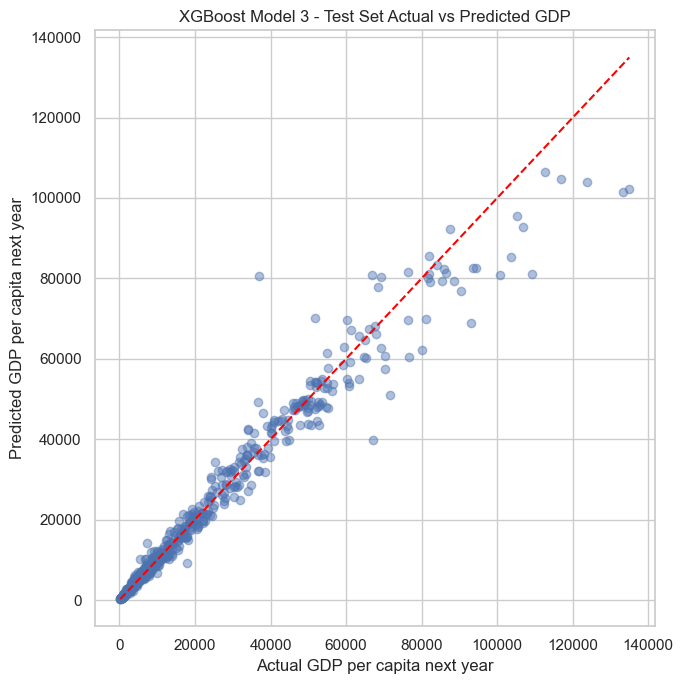

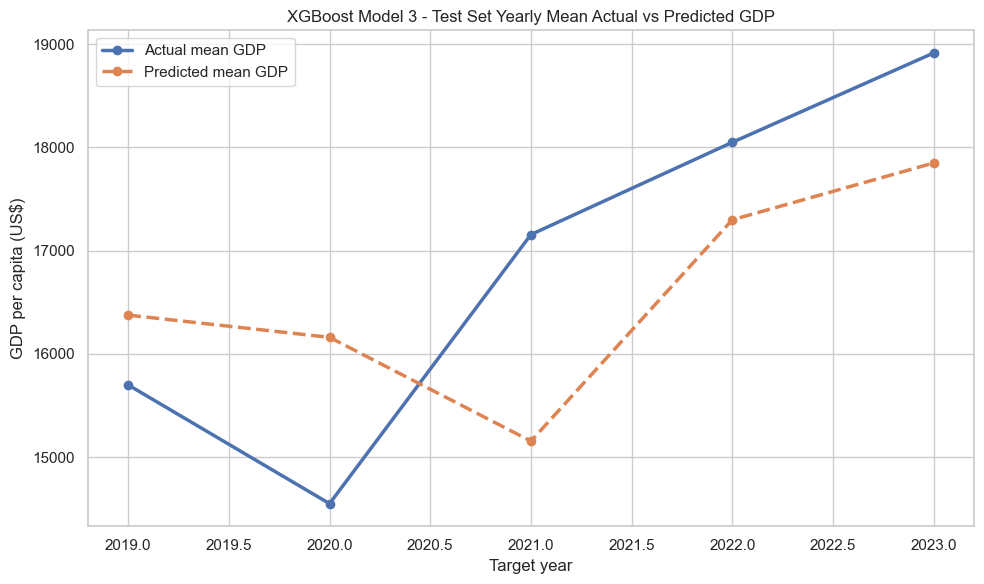

In [29]:
# Cell 6G - Quick plots for showing your lecturer

plt.figure(figsize=(7, 7))

plt.scatter(
    test_pred_df["actual_gdp_next_year"],
    test_pred_df["predicted_gdp_next_year"],
    alpha=0.45
)

min_val = min(test_pred_df["actual_gdp_next_year"].min(), test_pred_df["predicted_gdp_next_year"].min())
max_val = max(test_pred_df["actual_gdp_next_year"].max(), test_pred_df["predicted_gdp_next_year"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")
plt.title("XGBoost Model 3 - Test Set Actual vs Predicted GDP")
plt.xlabel("Actual GDP per capita next year")
plt.ylabel("Predicted GDP per capita next year")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    yearly_summary_df["target_year"],
    yearly_summary_df["mean_actual_gdp_next_year"],
    marker="o",
    linewidth=2.5,
    label="Actual mean GDP"
)

plt.plot(
    yearly_summary_df["target_year"],
    yearly_summary_df["mean_predicted_gdp_next_year"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Predicted mean GDP"
)

plt.title("XGBoost Model 3 - Test Set Yearly Mean Actual vs Predicted GDP")
plt.xlabel("Target year")
plt.ylabel("GDP per capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Cell 7 - Helper functions for future driver paths

def apply_bounds(values, lower_clip=None, upper_clip=None):
    arr = np.asarray(values, dtype=float)

    if lower_clip is not None:
        arr = np.maximum(arr, lower_clip)

    if upper_clip is not None:
        arr = np.minimum(arr, upper_clip)

    return arr


def forecast_country_series(series, model_name, forecast_horizon):
    series = pd.Series(series).dropna().astype(float)
    series = series[~series.index.duplicated(keep="last")]

    if forecast_horizon <= 0:
        return np.array([])

    if len(series) < 3:
        last_val = float(series.iloc[-1])
        return np.repeat(last_val, forecast_horizon)

    if model_name == "Naive":
        last_val = float(series.iloc[-1])
        return np.repeat(last_val, forecast_horizon)

    if model_name == "Holt":
        fitted = ExponentialSmoothing(
            series,
            trend="add",
            seasonal=None,
            initialization_method="estimated"
        ).fit(optimized=True)
        fc = fitted.forecast(forecast_horizon)
        return np.asarray(fc, dtype=float)

    if model_name == "LogHolt":
        safe_series = series.clip(lower=1)
        log_series = np.log(safe_series)
        fitted = ExponentialSmoothing(
            log_series,
            trend="add",
            seasonal=None,
            initialization_method="estimated"
        ).fit(optimized=True)
        fc = fitted.forecast(forecast_horizon)
        return np.exp(np.asarray(fc, dtype=float))

    raise ValueError(f"Unsupported model_name: {model_name}")


def build_actual_lookup(long_df, country_code, value_col, lower_clip=None, upper_clip=None):
    country_df = long_df[long_df["country_code"] == country_code].copy().sort_values("year")

    if country_df.empty:
        raise ValueError(f"No data found for country_code={country_code} in {value_col}")

    country_df[value_col] = pd.to_numeric(country_df[value_col], errors="coerce")
    country_df = country_df[country_df[value_col].notna()].copy()
    country_df[value_col] = apply_bounds(country_df[value_col].values, lower_clip=lower_clip, upper_clip=upper_clip)

    actual_lookup = dict(zip(country_df["year"], country_df[value_col]))
    last_actual_year = int(country_df["year"].max())

    return actual_lookup, last_actual_year, country_df


def build_forecast_lookup(long_df, country_code, value_col, forecast_to_year, model_name, lower_clip=None, upper_clip=None):
    country_df = long_df[long_df["country_code"] == country_code].copy().sort_values("year")

    if country_df.empty:
        raise ValueError(f"No data found for country_code={country_code} in {value_col}")

    country_df[value_col] = pd.to_numeric(country_df[value_col], errors="coerce")
    country_df = country_df[country_df[value_col].notna()].copy()
    country_df[value_col] = apply_bounds(country_df[value_col].values, lower_clip=lower_clip, upper_clip=upper_clip)

    actual_lookup = dict(zip(country_df["year"], country_df[value_col]))
    last_actual_year = int(country_df["year"].max())

    if forecast_to_year <= last_actual_year:
        return actual_lookup, last_actual_year, country_df

    horizon = forecast_to_year - last_actual_year
    series = country_df.set_index("year")[value_col]

    future_values = forecast_country_series(
        series=series,
        model_name=model_name,
        forecast_horizon=horizon
    )

    future_values = apply_bounds(future_values, lower_clip=lower_clip, upper_clip=upper_clip)

    future_lookup = {
        year: value
        for year, value in zip(range(last_actual_year + 1, forecast_to_year + 1), future_values)
    }

    full_lookup = {**actual_lookup, **future_lookup}
    return full_lookup, last_actual_year, country_df

In [31]:
# Cell 8 - Event helpers and region helpers

def build_event_features(feature_year):
    return {
        "asian_financial_crisis_9798": 1 if feature_year in [1997, 1998] else 0,
        "global_financial_crisis_0809": 1 if feature_year in [2008, 2009] else 0,
        "covid_shock_2020": 1 if feature_year == 2020 else 0,
        "covid_rebound_2021": 1 if feature_year == 2021 else 0,
        "ukraine_energy_shock_2022_2024": 1 if 2022 <= feature_year <= 2024 else 0,
    }


def build_region_feature_values(region_name, region_feature_map):
    region_values = {feature_name: 0 for feature_name in region_feature_map.values()}

    if region_name not in region_feature_map:
        raise ValueError(f"Region '{region_name}' was not found in training region map.")

    region_values[region_feature_map[region_name]] = 1
    return region_values

In [32]:
# Cell 9 - Build actual and future lookups

country_code_input = COUNTRY_CODE_INPUT.upper()

gdp_lookup, gdp_last_year, gdp_country_df = build_actual_lookup(
    gdp_long,
    country_code=country_code_input,
    value_col="gdp_per_capita_usd"
)

pop_lookup, pop_last_year, pop_country_df = build_forecast_lookup(
    pop_long,
    country_code=country_code_input,
    value_col="population_total",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=POP_FORECAST_MODEL,
    lower_clip=1
)

life_lookup, life_last_year, life_country_df = build_forecast_lookup(
    life_long,
    country_code=country_code_input,
    value_col="life_expectancy_years",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=LIFE_FORECAST_MODEL,
    lower_clip=0,
    upper_clip=120
)

inflation_lookup, inflation_last_year, inflation_country_df = build_forecast_lookup(
    inflation_long,
    country_code=country_code_input,
    value_col="inflation_pct",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=INFLATION_FORECAST_MODEL
)

unemployment_lookup, unemployment_last_year, unemployment_country_df = build_forecast_lookup(
    unemployment_long,
    country_code=country_code_input,
    value_col="unemployment_pct",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=UNEMPLOYMENT_FORECAST_MODEL,
    lower_clip=0,
    upper_clip=100
)

internet_lookup, internet_last_year, internet_country_df = build_forecast_lookup(
    internet_long,
    country_code=country_code_input,
    value_col="internet_users_pct",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=INTERNET_FORECAST_MODEL,
    lower_clip=0,
    upper_clip=100
)

country_name_value = gdp_country_df["country_name"].dropna().iloc[-1]
region_value = gdp_country_df["wb_region"].dropna().iloc[-1] if gdp_country_df["wb_region"].notna().any() else "Unknown"

print("Country:", country_name_value, f"({country_code_input})")
print("Region:", region_value)
print("Latest actual GDP year:", gdp_last_year)
print("Target forecast year:", TARGET_YEAR_INPUT)

print("GDP lookup years:", min(gdp_lookup.keys()), "-", max(gdp_lookup.keys()))
print("Population lookup years:", min(pop_lookup.keys()), "-", max(pop_lookup.keys()))
print("Life lookup years:", min(life_lookup.keys()), "-", max(life_lookup.keys()))
print("Inflation lookup years:", min(inflation_lookup.keys()), "-", max(inflation_lookup.keys()))
print("Unemployment lookup years:", min(unemployment_lookup.keys()), "-", max(unemployment_lookup.keys()))
print("Internet lookup years:", min(internet_lookup.keys()), "-", max(internet_lookup.keys()))

Country: Viet Nam (VNM)
Region: East Asia & Pacific
Latest actual GDP year: 2024
Target forecast year: 2040
GDP lookup years: 1985 - 2024
Population lookup years: 1960 - 2039
Life lookup years: 1960 - 2039
Inflation lookup years: 1996 - 2039
Unemployment lookup years: 1991 - 2039
Internet lookup years: 1990 - 2039


In [33]:
# Cell 10 - Recursive GDP forecast using XGBoost Model 3

def recursive_gdp_forecast_model_3(
    booster,
    country_code,
    country_name,
    region_name,
    target_year,
    gdp_lookup,
    pop_lookup,
    life_lookup,
    inflation_lookup,
    unemployment_lookup,
    internet_lookup,
    base_feature_year,
    region_feature_map
):
    actual_gdp_years = sorted(gdp_lookup.keys())
    latest_actual_gdp_year = max(actual_gdp_years)

    if target_year <= latest_actual_gdp_year:
        raise ValueError(
            f"Target year must be greater than the latest actual GDP year. "
            f"Latest actual GDP year for {country_code} is {latest_actual_gdp_year}, "
            f"but you entered {target_year}."
        )

    current_gdp = float(gdp_lookup[latest_actual_gdp_year])

    forecast_rows = []

    for forecast_year in range(latest_actual_gdp_year + 1, target_year + 1):
        feature_year = forecast_year - 1

        if feature_year not in pop_lookup:
            raise ValueError(f"Missing population value for feature year {feature_year}")
        if feature_year not in life_lookup:
            raise ValueError(f"Missing life expectancy value for feature year {feature_year}")
        if feature_year not in inflation_lookup:
            raise ValueError(f"Missing inflation value for feature year {feature_year}")
        if feature_year not in unemployment_lookup:
            raise ValueError(f"Missing unemployment value for feature year {feature_year}")
        if feature_year not in internet_lookup:
            raise ValueError(f"Missing internet value for feature year {feature_year}")

        pop_value = float(pop_lookup[feature_year])
        life_value = float(life_lookup[feature_year])
        inflation_value = float(inflation_lookup[feature_year])
        unemployment_value = float(unemployment_lookup[feature_year])
        internet_value = float(internet_lookup[feature_year])

        event_features = build_event_features(feature_year)
        region_features = build_region_feature_values(region_name, region_feature_map)

        feature_dict = {
            "log_gdp_per_capita": np.log(max(current_gdp, 1e-9)),
            "log_population_total": np.log(max(pop_value, 1e-9)),
            "life_expectancy_years": life_value,
            "inflation_pct_clean": inflation_value,
            "unemployment_pct_clean": unemployment_value,
            "internet_users_pct_clean": internet_value,
            "year_trend": feature_year - base_feature_year,
        }

        feature_dict.update(event_features)
        feature_dict.update(region_features)

        feature_frame = pd.DataFrame([feature_dict])
        feature_frame = feature_frame[feature_cols]

        dmatrix = xgb.DMatrix(feature_frame, feature_names=feature_cols)
        pred_log_gdp = float(booster.predict(dmatrix)[0])
        pred_gdp = float(np.exp(pred_log_gdp))

        forecast_rows.append(
            {
                "country_name": country_name,
                "country_code": country_code,
                "wb_region": region_name,
                "latest_actual_gdp_year": latest_actual_gdp_year,
                "feature_year_used": feature_year,
                "target_year": forecast_year,
                "gdp_input_used": current_gdp,
                "population_used": pop_value,
                "life_expectancy_used": life_value,
                "inflation_used": inflation_value,
                "unemployment_used": unemployment_value,
                "internet_users_used": internet_value,
                "year_trend_used": feature_year - base_feature_year,
                "asian_financial_crisis_9798": event_features["asian_financial_crisis_9798"],
                "global_financial_crisis_0809": event_features["global_financial_crisis_0809"],
                "covid_shock_2020": event_features["covid_shock_2020"],
                "covid_rebound_2021": event_features["covid_rebound_2021"],
                "ukraine_energy_shock_2022_2024": event_features["ukraine_energy_shock_2022_2024"],
                "predicted_log_gdp_per_capita": pred_log_gdp,
                "predicted_gdp_per_capita_usd": pred_gdp,
                "population_model": POP_FORECAST_MODEL,
                "life_model": LIFE_FORECAST_MODEL,
                "inflation_model": INFLATION_FORECAST_MODEL,
                "unemployment_model": UNEMPLOYMENT_FORECAST_MODEL,
                "internet_model": INTERNET_FORECAST_MODEL,
                "gdp_model": "XGBoost Model 3 Recursive"
            }
        )

        current_gdp = pred_gdp

    return pd.DataFrame(forecast_rows)

In [34]:
# Cell 11 - Run forecast

forecast_model_3_df = recursive_gdp_forecast_model_3(
    booster=final_model_3,
    country_code=country_code_input,
    country_name=country_name_value,
    region_name=region_value,
    target_year=TARGET_YEAR_INPUT,
    gdp_lookup=gdp_lookup,
    pop_lookup=pop_lookup,
    life_lookup=life_lookup,
    inflation_lookup=inflation_lookup,
    unemployment_lookup=unemployment_lookup,
    internet_lookup=internet_lookup,
    base_feature_year=BASE_FEATURE_YEAR,
    region_feature_map=region_feature_map
)

display(forecast_model_3_df.head(10))
display(forecast_model_3_df.tail(10))

,country_name,country_code,wb_region,latest_actual_gdp_year,feature_year_used,target_year,gdp_input_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,year_trend_used,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,predicted_log_gdp_per_capita,predicted_gdp_per_capita_usd,population_model,life_model,inflation_model,unemployment_model,internet_model,gdp_model
0,Viet Nam,VNM,East Asia & Pacific,2024,2024,2025,"4,717.2903","100,987,686.0000",74.8784,3.6211,1.6020,84.1500,33,0,0,0,0,1,8.5775,"5,310.6516",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,2026,"5,310.6516","101,627,204.3534",75.1413,3.6211,1.5230,87.7962,34,0,0,0,0,0,8.7207,"6,128.2237",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
2,Viet Nam,VNM,East Asia & Pacific,2024,2026,2027,"6,128.2237","102,270,772.5438",75.4042,3.6211,1.5230,91.4425,35,0,0,0,0,0,8.8350,"6,870.3510",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
3,Viet Nam,VNM,East Asia & Pacific,2024,2027,2028,"6,870.3510","102,918,416.2179",75.6671,3.6211,1.5230,95.0887,36,0,0,0,0,0,8.9444,"7,664.9494",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
4,Viet Nam,VNM,East Asia & Pacific,2024,2028,2029,"7,664.9494","103,570,161.1842",75.9300,3.6211,1.5230,98.7350,37,0,0,0,0,0,9.0626,"8,626.1651",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
5,Viet Nam,VNM,East Asia & Pacific,2024,2029,2030,"8,626.1651","104,226,033.4148",76.1929,3.6211,1.5230,100.0000,38,0,0,0,0,0,9.1985,"9,881.8201",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
6,Viet Nam,VNM,East Asia & Pacific,2024,2030,2031,"9,881.8201","104,886,059.0461",76.4558,3.6211,1.5230,100.0000,39,0,0,0,0,0,9.2960,"10,894.3390",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
7,Viet Nam,VNM,East Asia & Pacific,2024,2031,2032,"10,894.3390","105,550,264.3802",76.7187,3.6211,1.5230,100.0000,40,0,0,0,0,0,9.3849,"11,907.0595",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
8,Viet Nam,VNM,East Asia & Pacific,2024,2032,2033,"11,907.0595","106,218,675.8855",76.9816,3.6211,1.5230,100.0000,41,0,0,0,0,0,9.4237,"12,378.0771",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
9,Viet Nam,VNM,East Asia & Pacific,2024,2033,2034,"12,378.0771","106,891,320.1982",77.2445,3.6211,1.5230,100.0000,42,0,0,0,0,0,9.4621,"12,862.3778",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive


,country_name,country_code,wb_region,latest_actual_gdp_year,feature_year_used,target_year,gdp_input_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,year_trend_used,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,predicted_log_gdp_per_capita,predicted_gdp_per_capita_usd,population_model,life_model,inflation_model,unemployment_model,internet_model,gdp_model
6,Viet Nam,VNM,East Asia & Pacific,2024,2030,2031,"9,881.8201","104,886,059.0461",76.4558,3.6211,1.5230,100.0000,39,0,0,0,0,0,9.2960,"10,894.3390",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
7,Viet Nam,VNM,East Asia & Pacific,2024,2031,2032,"10,894.3390","105,550,264.3802",76.7187,3.6211,1.5230,100.0000,40,0,0,0,0,0,9.3849,"11,907.0595",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
8,Viet Nam,VNM,East Asia & Pacific,2024,2032,2033,"11,907.0595","106,218,675.8855",76.9816,3.6211,1.5230,100.0000,41,0,0,0,0,0,9.4237,"12,378.0771",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
9,Viet Nam,VNM,East Asia & Pacific,2024,2033,2034,"12,378.0771","106,891,320.1982",77.2445,3.6211,1.5230,100.0000,42,0,0,0,0,0,9.4621,"12,862.3778",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
10,Viet Nam,VNM,East Asia & Pacific,2024,2034,2035,"12,862.3778","107,568,224.1231",77.5074,3.6211,1.5230,100.0000,43,0,0,0,0,0,9.4973,"13,323.0836",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
11,Viet Nam,VNM,East Asia & Pacific,2024,2035,2036,"13,323.0836","108,249,414.6348",77.7703,3.6211,1.5230,100.0000,44,0,0,0,0,0,9.6106,"14,922.6827",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
12,Viet Nam,VNM,East Asia & Pacific,2024,2036,2037,"14,922.6827","108,934,918.8788",78.0332,3.6211,1.5230,100.0000,45,0,0,0,0,0,9.6647,"15,751.5015",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
13,Viet Nam,VNM,East Asia & Pacific,2024,2037,2038,"15,751.5015","109,624,764.1722",78.2961,3.6211,1.5230,100.0000,46,0,0,0,0,0,9.6780,"15,962.4101",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
14,Viet Nam,VNM,East Asia & Pacific,2024,2038,2039,"15,962.4101","110,318,978.0055",78.5590,3.6211,1.5230,100.0000,47,0,0,0,0,0,9.7758,"17,602.1929",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive
15,Viet Nam,VNM,East Asia & Pacific,2024,2039,2040,"17,602.1929","111,017,588.0429",78.8219,3.6211,1.5230,100.0000,48,0,0,0,0,0,9.8457,"18,876.7258",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 3 Recursive


In [35]:
# Cell 12 - Clean output table

output_df = forecast_model_3_df[
    [
        "target_year",
        "population_used",
        "life_expectancy_used",
        "inflation_used",
        "unemployment_used",
        "internet_users_used",
        "year_trend_used",
        "asian_financial_crisis_9798",
        "global_financial_crisis_0809",
        "covid_shock_2020",
        "covid_rebound_2021",
        "ukraine_energy_shock_2022_2024",
        "predicted_gdp_per_capita_usd"
    ]
].copy()

output_df["population_used"] = output_df["population_used"].round(0).astype("int64")
output_df["life_expectancy_used"] = output_df["life_expectancy_used"].round(2)
output_df["inflation_used"] = output_df["inflation_used"].round(2)
output_df["unemployment_used"] = output_df["unemployment_used"].round(2)
output_df["internet_users_used"] = output_df["internet_users_used"].round(2)
output_df["predicted_gdp_per_capita_usd"] = output_df["predicted_gdp_per_capita_usd"].round(2)

display(output_df)

,target_year,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,year_trend_used,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,predicted_gdp_per_capita_usd
0,2025,100987686,74.8800,3.6200,1.6000,84.1500,33,0,0,0,0,1,"5,310.6500"
1,2026,101627204,75.1400,3.6200,1.5200,87.8000,34,0,0,0,0,0,"6,128.2200"
2,2027,102270773,75.4000,3.6200,1.5200,91.4400,35,0,0,0,0,0,"6,870.3500"
3,2028,102918416,75.6700,3.6200,1.5200,95.0900,36,0,0,0,0,0,"7,664.9500"
4,2029,103570161,75.9300,3.6200,1.5200,98.7300,37,0,0,0,0,0,"8,626.1700"
5,2030,104226033,76.1900,3.6200,1.5200,100.0000,38,0,0,0,0,0,"9,881.8200"
6,2031,104886059,76.4600,3.6200,1.5200,100.0000,39,0,0,0,0,0,"10,894.3400"
7,2032,105550264,76.7200,3.6200,1.5200,100.0000,40,0,0,0,0,0,"11,907.0600"
8,2033,106218676,76.9800,3.6200,1.5200,100.0000,41,0,0,0,0,0,"12,378.0800"
9,2034,106891320,77.2400,3.6200,1.5200,100.0000,42,0,0,0,0,0,"12,862.3800"


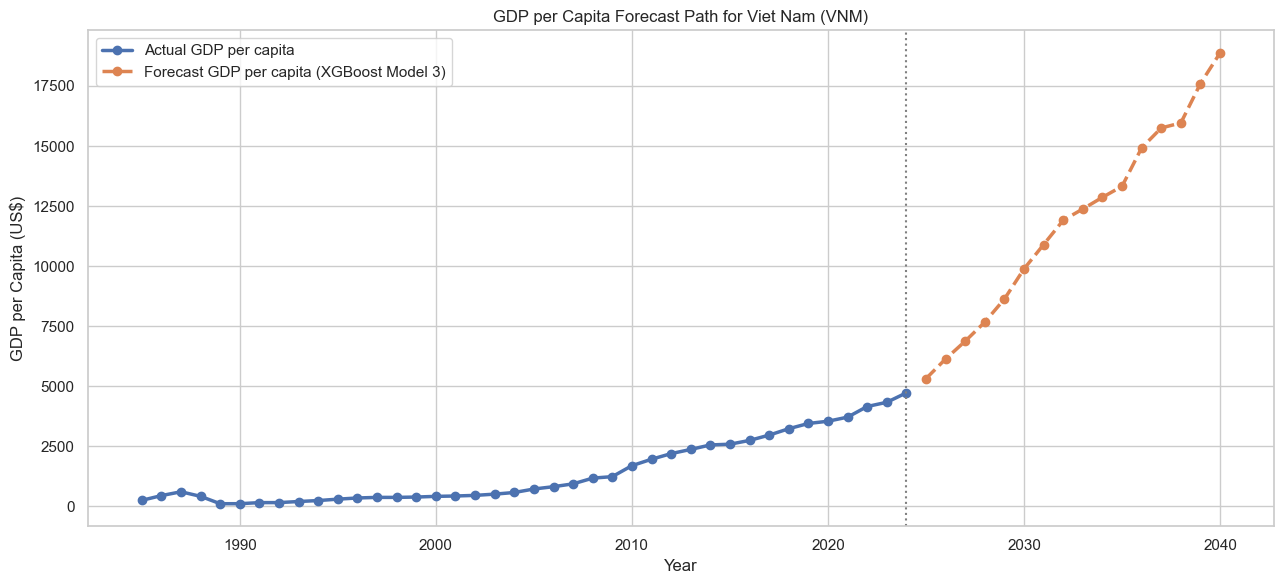

In [36]:
# Cell 13 - Plot GDP forecast path

historical_plot_df = gdp_country_df[["year", "gdp_per_capita_usd"]].copy()
historical_plot_df = historical_plot_df.rename(columns={"year": "target_year"})
historical_plot_df["series_type"] = "Actual GDP per capita"

future_plot_df = forecast_model_3_df[["target_year", "predicted_gdp_per_capita_usd"]].copy()
future_plot_df = future_plot_df.rename(columns={"predicted_gdp_per_capita_usd": "gdp_per_capita_usd"})
future_plot_df["series_type"] = "Forecast GDP per capita"

plot_df = pd.concat([historical_plot_df, future_plot_df], ignore_index=True)

plt.figure(figsize=(13, 6))

actual_df = plot_df[plot_df["series_type"] == "Actual GDP per capita"]
forecast_df = plot_df[plot_df["series_type"] == "Forecast GDP per capita"]

plt.plot(
    actual_df["target_year"],
    actual_df["gdp_per_capita_usd"],
    marker="o",
    linewidth=2.5,
    label="Actual GDP per capita"
)

plt.plot(
    forecast_df["target_year"],
    forecast_df["gdp_per_capita_usd"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Forecast GDP per capita (XGBoost Model 3)"
)

plt.axvline(x=int(actual_df["target_year"].max()), color="gray", linestyle=":", linewidth=1.5)
plt.title(f"GDP per Capita Forecast Path for {country_name_value} ({country_code_input})")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Cell 14 - Inspect future drivers and event flags

driver_preview_df = forecast_model_3_df[
    [
        "feature_year_used",
        "population_used",
        "life_expectancy_used",
        "inflation_used",
        "unemployment_used",
        "internet_users_used",
        "year_trend_used",
        "asian_financial_crisis_9798",
        "global_financial_crisis_0809",
        "covid_shock_2020",
        "covid_rebound_2021",
        "ukraine_energy_shock_2022_2024"
    ]
].copy()

display(driver_preview_df.head(20))
display(driver_preview_df.tail(20))

,feature_year_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,year_trend_used,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024
0,2024,"100,987,686.0000",74.8784,3.6211,1.6020,84.1500,33,0,0,0,0,1
1,2025,"101,627,204.3534",75.1413,3.6211,1.5230,87.7962,34,0,0,0,0,0
2,2026,"102,270,772.5438",75.4042,3.6211,1.5230,91.4425,35,0,0,0,0,0
3,2027,"102,918,416.2179",75.6671,3.6211,1.5230,95.0887,36,0,0,0,0,0
4,2028,"103,570,161.1842",75.9300,3.6211,1.5230,98.7350,37,0,0,0,0,0
5,2029,"104,226,033.4148",76.1929,3.6211,1.5230,100.0000,38,0,0,0,0,0
6,2030,"104,886,059.0461",76.4558,3.6211,1.5230,100.0000,39,0,0,0,0,0
7,2031,"105,550,264.3802",76.7187,3.6211,1.5230,100.0000,40,0,0,0,0,0
8,2032,"106,218,675.8855",76.9816,3.6211,1.5230,100.0000,41,0,0,0,0,0
9,2033,"106,891,320.1982",77.2445,3.6211,1.5230,100.0000,42,0,0,0,0,0


,feature_year_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,year_trend_used,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024
0,2024,"100,987,686.0000",74.8784,3.6211,1.6020,84.1500,33,0,0,0,0,1
1,2025,"101,627,204.3534",75.1413,3.6211,1.5230,87.7962,34,0,0,0,0,0
2,2026,"102,270,772.5438",75.4042,3.6211,1.5230,91.4425,35,0,0,0,0,0
3,2027,"102,918,416.2179",75.6671,3.6211,1.5230,95.0887,36,0,0,0,0,0
4,2028,"103,570,161.1842",75.9300,3.6211,1.5230,98.7350,37,0,0,0,0,0
5,2029,"104,226,033.4148",76.1929,3.6211,1.5230,100.0000,38,0,0,0,0,0
6,2030,"104,886,059.0461",76.4558,3.6211,1.5230,100.0000,39,0,0,0,0,0
7,2031,"105,550,264.3802",76.7187,3.6211,1.5230,100.0000,40,0,0,0,0,0
8,2032,"106,218,675.8855",76.9816,3.6211,1.5230,100.0000,41,0,0,0,0,0
9,2033,"106,891,320.1982",77.2445,3.6211,1.5230,100.0000,42,0,0,0,0,0


In [38]:
# Cell 15 - Save output

save_path = CLEAN_DIR / f"gdp_xgboost_model_3_future_forecast_{country_code_input}_{TARGET_YEAR_INPUT}.csv"
forecast_model_3_df.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_3_future_forecast_VNM_2040.csv


In [39]:
# Cell 16 - Quick summary

latest_forecast_row = forecast_model_3_df.iloc[-1]

print("=== MODEL 3 FUTURE FORECAST SUMMARY ===")
print("Country:", latest_forecast_row["country_name"], f"({latest_forecast_row['country_code']})")
print("Region:", latest_forecast_row["wb_region"])
print("Target year:", int(latest_forecast_row["target_year"]))
print("Predicted GDP per capita (US$):", round(float(latest_forecast_row["predicted_gdp_per_capita_usd"]), 2))
print("Population model used:", latest_forecast_row["population_model"])
print("Life model used:", latest_forecast_row["life_model"])
print("Inflation model used:", latest_forecast_row["inflation_model"])
print("Unemployment model used:", latest_forecast_row["unemployment_model"])
print("Internet model used:", latest_forecast_row["internet_model"])
print("GDP model used:", latest_forecast_row["gdp_model"])

=== MODEL 3 FUTURE FORECAST SUMMARY ===
Country: Viet Nam (VNM)
Region: East Asia & Pacific
Target year: 2040
Predicted GDP per capita (US$): 18876.73
Population model used: LogHolt
Life model used: Holt
Inflation model used: Naive
Unemployment model used: Naive
Internet model used: Holt
GDP model used: XGBoost Model 3 Recursive
